<img src="https://raw.githubusercontent.com/KartikNW/MSDS_453_Public/main/images/NorthwesternHeader.png">

In [1]:
NOTEBOOK_VERSION = "32.0"
QUARTER = "Fall 2026"

# The class corpus for this term. This URL always points at the current one.
CORPUS_URL = "https://raw.githubusercontent.com/KartikNW/MSDS_453_Public/main/MSDS453_ClassCorpus/class_corpus.csv"

# Used only when the class corpus for this term is not available. A frozen
# teaching set, not this term's reviews. See load_corpus().
SAMPLE_CORPUS_URL = "https://raw.githubusercontent.com/KartikNW/MSDS_453_Public/main/MSDS453_ClassCorpus/sample_corpus.csv"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 32.0 | Fall 2026


## MSDS453 - Research Assignment 03 - Ontology Plus Context and Modeling

Take the ontology that you developed in week 6 and consider how your ten chosen documents for this quarter's class corpus map to that ontology.

Protégé is a tool that takes inputs for a human-created Ontology and creates a visualization.

Use Python algorithms to generate Knowledge Graphs from your documents.

TensorFlow Bidirectional RNN Model

In [2]:
!pip install -U "gensim>=4.4.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 48.2 MB/s eta 0:00:00


In [3]:
import gensim, numpy as np, scipy, sys

print("Python:", sys.version)
print("gensim:", gensim.__version__)
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
gensim: 4.4.0
numpy : 2.1.3
scipy : 1.16.3


In [4]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from collections import Counter
from dataclasses import dataclass
from timeit import default_timer as timer

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import gensim
from gensim.models import Word2Vec

import spacy
from spacy import displacy

from spacy.matcher import Matcher
from spacy.tokens import Span

import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from IPython.display import display, HTML

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(2022)
import tensorflow.keras.backend as k

from typing import List, Callable, Dict, Tuple, Set

from transformers import pipeline

<div class="alert alert-block alert-danger">
<b>Required Installation: en_core_web_lg</b><br>"python -m spacy download en_core_web_lg"<br><br>English pipeline optimized for CPU. Components: tok2vec, tagger, parser, senter, ner, attribute_ruler, lemmatizer<br>
    <b>https://spacy.io/models/en#en_core_web_lg </b>
</div>

## Requires Restart Of Runtime After Installation

In [5]:
!python -m spacy download en_core_web_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
nlp = spacy.load('en_core_web_lg')

### Mount Google Drive to Colab Environment

In [7]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [8]:
#! ls -l /content/gdrive

### NLTK Downloads

In [9]:
# Only run this once, they will be downloaded.
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
nltk.download('punkt',quiet=True)
nltk.download('omw-1.4',quiet=True)
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

<div class="alert alert-block alert-danger">
<b>Gensim</b> is a Python library for topic modelling, document indexing and similarity retrieval with large corpora. Target audience is the natural language processing (NLP) and information retrieval (IR) community <br><br>
    <b>https://pypi.org/project/gensim/ </b>
</div>

In [10]:
import pkg_resources
#pkg_resources.require("gensim<=3.8.3");

/tmp/ipykernel_1353/2941816030.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [11]:
print("Genism Version: ", gensim.__version__)

Genism Version:  4.4.0


<div class="alert alert-block alert-info">
    <b>Suppress warning messages</b></div>

In [12]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## Data Wrangling Utility Functions

In [13]:
def add_movie_descriptor(data: pd.DataFrame, corpus_df: pd.DataFrame):
    """
    Adds "Movie Description" to the supplied dataframe, in the form {Genre}_{P|N}_{Movie Title}_{DocID}
    """
    review = np.where(corpus_df['Review Type (pos or neg)'] == 'Positive', 'P', 'N')
    data['Descriptor'] = corpus_df['Genre of Movie'] + '_' + corpus_df['Movie Title'] + '_' + review + '_' + corpus_df['Doc_ID'].astype(str)

def get_corpus_df(path: str) -> pd.DataFrame:
    data = pd.read_csv(path,encoding="utf-8")
    add_movie_descriptor(data, data)
    sorted_data = data.sort_values(['Descriptor'])
    indexed_data = sorted_data.set_index(['Doc_ID'])
    indexed_data['Doc_ID'] = indexed_data.index
    return indexed_data

def remove_punctuation(text: str) -> str:
    return re.sub('[^a-zA-Z]', '', str(text))

def remove_tags(text: str) -> str:
    return re.sub('&lt;/?.*?&gt;', '', text)

def remove_special_chars_and_digits(text: str) -> str:
    return re.sub('(\\d|\\W)+', '', text)

def get_sentences(text: str) -> List[str]:
    return [str(x) for x in nlp(text).sents]

def get_coref_resolved_sentences(text: str) -> List[str]:
    return [str(x) for x in nlp(text).sents]

def get_lemmas(text: str, stopwords: Set[str]) -> List[str]:
    initial = [remove_tags(remove_special_chars_and_digits(remove_punctuation(x.lemma_.lower()))) for x in nlp(text)]
    return [x for x in initial if x not in stopwords]

def lemmatize_sentence(text: str, stopwords: Set[str]) -> str:
    return ' '.join(get_lemmas(text, stopwords))

def clean_doc(doc):
    #doc = remove_punctuation(doc)
    doc= ' '.join(remove_stop_words(doc))
    doc = apply_lemmatization(doc)
    return doc

def remove_stop_words(in_text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(in_text)
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    return filtered_sentence

def apply_lemmatization(in_text):
    # Lemmatization
    lem = WordNetLemmatizer()
    word_list = nltk.word_tokenize(in_text)
    output = ' '.join([lem.lemmatize(w) for w in word_list])
    return output

def counter_word(text):
  count=Counter()
  for i in text.values:
    for word in i.split():
      count[word]=+1
  return count

## Knowledge Context Graph Functions

In [14]:
def map_edges(map_to: str, map_from: Set[str], df: pd.DataFrame):
    print(f'Before mapping {", ".join(map_from)} -> {map_to}: {sum(df.edge == map_to)}')
    df['edge'] = np.where(kg_df.edge.isin(map_from), map_to, kg_df.edge)
    print(f'After mapping {", ".join(map_from)} -> {map_to}: {sum(df.edge == map_to)}')

def map_sources_and_targets(map_to: str, map_from: Set[str], df: pd.DataFrame):
    before = sum(df.source == map_to) + sum(df.target == map_to)
    print(f'Before mapping {", ".join(map_from)} -> {map_to}: {before}')

    df['source'] = np.where(kg_df.source.isin(map_from), map_to, kg_df.source)
    df['target'] = np.where(kg_df.target.isin(map_from), map_to, kg_df.target)

    after = sum(df.source == map_to) + sum(df.target == map_to)
    print(f'After mapping {", ".join(map_from)} -> {map_to}: {after}')

def get_neighborhood(sources: Set[str], edge_types: Set[str], depth: int, df: pd.DataFrame) -> pd.DataFrame:
    output = []

    for d in range(depth):
        if edge_types is not None:
            rows = df[(df.edge.isin(edge_types)) & ((df.source.isin(sources)) | (df.target.isin(sources)))].copy()
        else:
            rows = df[(df.source.isin(sources)) | (df.target.isin(sources))].copy()

        output.append(rows)
        sources = set(rows.target).union(set(rows.source))

    return pd.concat(output).drop_duplicates()

def find_sources_and_targets_with_patterns(patterns: List[str], df: pd.DataFrame):
    mask = np.zeros(kg_df.shape[0])
    for pattern in patterns:
        mask = mask | (df.source.str.contains(pattern)) | (df.target.str.contains(pattern))

    return df[mask]
# Examples of how to use the function:
# find_sources_and_targets_with_patterns(['action'], kg_df)
# find_sources_and_targets_with_patterns(['terror'], kg_df)
# find_sources_and_targets_with_patterns(['novel'], kg_df)
# find_sources_and_targets_with_patterns(['director', 'campbell'], kg_df)


def plot_graph(df: pd.DataFrame, show_edges: bool = False, figsize: Tuple[int, int] = (12, 12), use_circular: bool=True):
    graph = nx.from_pandas_edgelist(df, "source", "target", edge_attr='edge', create_using=nx.MultiDiGraph())

    plt.figure(figsize=figsize)
    if use_circular:
        pos = nx.circular_layout(graph)
    else:
        pos = nx.kamada_kawai_layout(graph)

    nx.draw(graph, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos=pos)
    if show_edges:
        nx.draw_networkx_edge_labels(graph, pos=pos, font_size=8)

    plt.show()

def get_top_sources_and_targets(df: pd.DataFrame, top: int = 10):
    return (Counter(df.source) + Counter(df.target)).most_common(top)

def get_top_edges(df: pd.DataFrame, top: int = 10):
    return Counter(df.edge).most_common(top)

def get_dataset_partitions_pd(df, train_split=0.8, val_split=0.10, test_split=0.10):
       # Specify seed to always have the same split distribution between runs
    df_sample = df.sample(frac=1, random_state=12)
    indices_or_sections = [int(.8*len(df)), int(.9*len(df))]
    train_ds, val_ds, test_ds = np.split(df_sample, indices_or_sections)
    return train_ds, val_ds, test_ds

## Entity Extraction Functions

In [15]:
def get_entities(sent):
  ## chunk 1
  ent1 = ""
  ent2 = ""

  prv_tok_dep = ""    # dependency tag of previous token in the sentence
  prv_tok_text = ""   # previous token in the sentence

  prefix = ""
  modifier = ""

  for tok in nlp(sent):
    ## chunk 2
    # if token is a punctuation mark then move on to the next token
    if tok.dep_ != "punct":
      # check: token is a compound word or not
      if tok.dep_ == "compound":
        prefix = tok.text
        # if the previous word was also a 'compound' then add the current word to it
        if prv_tok_dep == "compound":
          prefix = prv_tok_text + " "+ tok.text

      # check: token is a modifier or not
      if tok.dep_.endswith("mod") == True:
        modifier = tok.text
        # if the previous word was also a 'compound' then add the current word to it
        if prv_tok_dep == "compound":
          modifier = prv_tok_text + " "+ tok.text

      ## chunk 3
      if tok.dep_.find("subj") == True:
        ent1 = modifier +" "+ prefix + " "+ tok.text
        prefix = ""
        modifier = ""
        prv_tok_dep = ""
        prv_tok_text = ""

      ## chunk 4
      if tok.dep_.find("obj") == True:
        ent2 = modifier +" "+ prefix +" "+ tok.text

      ## chunk 5
      # update variables
      prv_tok_dep = tok.dep_
      prv_tok_text = tok.text

  return [ent1.strip(), ent2.strip()]

def get_relation(sent):
    try:
        doc = nlp(sent)

        # Matcher class object
        matcher = Matcher(nlp.vocab)

        #define the pattern
        pattern = [{'DEP':'ROOT'},
                {'DEP':'prep','OP':"?"},
                {'DEP':'agent','OP':"?"},
                {'POS':'ADJ','OP':"?"}]
        matcher.add("matching_1", [pattern])
        matches = matcher(doc)
        k = len(matches) - 1
        span = doc[matches[k][1]:matches[k][2]]

        return(span.text)
    except:
        pass

def get_subject_verb_object(sent):
  ent1 = ""
  ent2 = ""
  root = ""

  for tok in nlp(sent):
      if tok.dep_ == 'ROOT':
        root = tok.text
      elif tok.dep_ == "nsubj":
        ent1 = tok.text
      elif tok.dep_ == "dobj":
        ent2 = tok.text

      if ent1 != '' and ent2 != '' and root != '':
        break

  return [ent1, root, ent2]

## Visualization Utility Functions

In [16]:
def plot_confusion_matrix_labeled(y_true, y_pred, CLASSES_LIST):
    mtx = confusion_matrix(y_true, y_pred)
    # define classes
    classes = CLASSES_LIST
    temp_df = pd.DataFrame(data=mtx,columns=classes)
    temp_df.index = classes
    fig, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(temp_df, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

## Loading the Class Corpus

In [17]:
# Corpus loading. The class corpus is used only if its Quarter column matches
# QUARTER; otherwise the sample corpus is used.
#
#   matches, complete     use it
#   matches, incomplete   use it, warn
#   matches, malformed    raise
#   anything else         sample corpus
#
# The class corpus is built from Discussion 01 submissions, so early in the term
# it does not exist yet and the sample path is the normal one.
#
# A malformed class corpus raises rather than falling back, so that a problem
# with the corpus cannot be mistaken for a result.
CORPUS_REQUIRED_COLUMNS = [
    "Doc_ID", "DSI_Title", "Submission File Name", "Student Name",
    "Genre of Movie", "Review Type (pos or neg)", "Movie Title", "Text",
]
CORPUS_EXPECTED_DOCUMENTS = 50   # below this, assume still being assembled
CORPUS_EXPECTED_MOVIES = 5

_corpus_cache = {}

def _is_this_quarters(df, quarter):
    """True if the corpus declares `quarter`."""
    if "Quarter" not in df.columns:
        return False
    return sorted(df["Quarter"].dropna().astype(str).unique()) == [quarter]

def _corpus_defects(df):
    """Faults that make the corpus unusable."""
    missing = [c for c in CORPUS_REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        return [f"missing column(s): {', '.join(missing)}"]

    defects = []
    dupes = df["Doc_ID"][df["Doc_ID"].duplicated()].unique()
    if len(dupes):
        defects.append(f"duplicate Doc_ID(s): {', '.join(map(str, dupes[:5]))}")
    empty = df["Text"].isna() | (df["Text"].astype(str).str.len() < 100)
    if empty.any():
        ids = df.loc[empty, "Doc_ID"].astype(str).tolist()[:5]
        defects.append(f"{empty.sum()} document(s) with empty or very short Text "
                       f"(Doc_ID {', '.join(ids)})")
    return defects

def _corpus_shortfalls(df):
    """Signs the corpus is still being assembled."""
    short = []
    if len(df) < CORPUS_EXPECTED_DOCUMENTS:
        short.append(f"only {len(df)} documents")
    if df["Movie Title"].nunique() < CORPUS_EXPECTED_MOVIES:
        short.append(f"only {df['Movie Title'].nunique()} movies")
    return short

def load_corpus(url=None, sample_url=None, quarter=None):
    """Return (dataframe, using_sample). Cached after the first call."""
    url = CORPUS_URL if url is None else url
    sample_url = SAMPLE_CORPUS_URL if sample_url is None else sample_url
    quarter = QUARTER if quarter is None else quarter
    bar = "=" * 74

    if _corpus_cache:
        return _corpus_cache["df"].copy(), _corpus_cache["using_sample"]

    try:
        df = get_corpus_df(url)
        mine = _is_this_quarters(df, quarter)
    except Exception:
        df, mine = None, False   # unreadable, so not this quarter's

    if mine:
        defects = _corpus_defects(df)
        if defects:
            raise ValueError(
                f"The {quarter} class corpus is published but unusable: "
                + "; ".join(defects)
                + ". This is a problem with the corpus, not with your notebook. "
                  "Please report it on the discussion board, quoting the "
                  "notebook version printed in the first cell."
            )
        shortfalls = _corpus_shortfalls(df)
        if shortfalls:
            print(bar)
            print("  !   THE CLASS CORPUS LOOKS INCOMPLETE")
            print(bar)
            print(f"  It is the {quarter} corpus, but it has "
                  + " and ".join(shortfalls) + ".")
            print("  Continuing with it. It may still be being assembled, so")
            print("  re-run this cell later and check these numbers again.")
            print(bar)
        print(f"Corpus: {url.rsplit('/', 1)[-1]} | {len(df)} documents | "
              f"{df['Movie Title'].nunique()} movies | {quarter}")
        _corpus_cache.update(df=df, using_sample=False)
        return df.copy(), False

    try:
        df = get_corpus_df(sample_url)
    except Exception as exc:
        raise RuntimeError(
            f"The {quarter} class corpus is not available, and the sample corpus "
            f"at {sample_url} could not be loaded either "
            f"({type(exc).__name__}: {exc}). Check your internet connection, "
            f"then ask on the discussion board."
        ) from exc

    print(bar)
    print("  !!  USING THE SAMPLE CORPUS, NOT YOUR CLASS CORPUS")
    print(bar)
    print(f"  The published class corpus is not the {quarter} class corpus.")
    print("  This is expected early in the term: your class corpus is built")
    print("  from Discussion 01 submissions and published after they close.")
    print()
    print("  The sample corpus is a frozen teaching set. It does not contain")
    print("  your review, or anyone's from this term. Re-run this cell once")
    print("  your class corpus is published, and write your report from that.")
    print(bar)
    print(f"Corpus: {sample_url.rsplit('/', 1)[-1]} | {len(df)} documents | "
          f"{df['Movie Title'].nunique()} movies | SAMPLE")
    _corpus_cache.update(df=df, using_sample=True)
    return df.copy(), True
corpus_df, USING_SAMPLE_CORPUS = load_corpus()

  !!  USING THE SAMPLE CORPUS, NOT YOUR CLASS CORPUS
  The published class corpus is not the Fall 2026 class corpus.
  This is expected early in the term: your class corpus is built
  from Discussion 01 submissions and published after they close.

  The sample corpus is a frozen teaching set. It does not contain
  your review, or anyone's from this term. Re-run this cell once
  your class corpus is published, and write your report from that.
Corpus: sample_corpus.csv | 200 documents | 20 movies | SAMPLE


## Exploratory Data Analysis

In [18]:
# Tokenize sentences
corpus_df['raw_sentences'] = corpus_df.Text.apply(get_sentences)
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Tokenize Words

In [19]:
default_stopwords=\
set(nltk.corpus.stopwords.words('english')).union(set(nlp.Defaults.stop_words)).union({' ', ''})
corpus_df['lemmas'] = corpus_df.Text.apply(lambda x: get_lemmas(x, default_stopwords))
corpus_df.lemmas.head()

,lemmas
Doc_ID,
40,"[boredom, set, long, start, angel, fall, start..."
41,"[people, mutter, enter, screening, angel, fall..."
42,"[ric, roman, waughs, angel, fallen, secret, se..."
43,"[certain, mindless, pleasure, fallen, movie, w..."
44,"[dont, need, olympus, fallen, andor, london, f..."


In [20]:
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Reassemble Leminized Words

In [21]:
corpus_df['lemmas_joined'] = corpus_df.lemmas.apply(lambda x: ' '.join(x))

In [22]:
corpus_df['lemmas_joined'].head()

,lemmas_joined
Doc_ID,
40,boredom set long start angel fall start journe...
41,people mutter enter screening angel fallen loc...
42,ric roman waughs angel fallen secret service a...
43,certain mindless pleasure fallen movie watch g...
44,dont need olympus fallen andor london fallen u...


In [23]:
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Vocabulary Data Wrangling

In [24]:
vectorizer = CountVectorizer(ngram_range=(1, 1))
transformed_documents = vectorizer.fit_transform(corpus_df.lemmas_joined)
doc_term_matrix = transformed_documents.todense()
doc_term_df = pd.DataFrame(doc_term_matrix,
                           columns=vectorizer.get_feature_names_out(),
                           index=corpus_df.Descriptor)
print(f'All Word Vocabulary size: {doc_term_df.shape[1]}')
all_words = set(doc_term_df.columns)

vectorizer = CountVectorizer(ngram_range=(1, 1), min_df=5, max_df=.8)
transformed_documents = vectorizer.fit_transform(corpus_df.lemmas_joined)
doc_term_matrix = transformed_documents.todense()
doc_term_df = pd.DataFrame(doc_term_matrix,
                           columns=vectorizer.get_feature_names_out(),
                           index=corpus_df.Descriptor)
print(f'Curated Vocabulary size: {doc_term_df.shape[1]}')
vocabulary = set(doc_term_df.columns)

words_to_remove = default_stopwords.union(all_words - vocabulary)

All Word Vocabulary size: 12170
Curated Vocabulary size: 2911


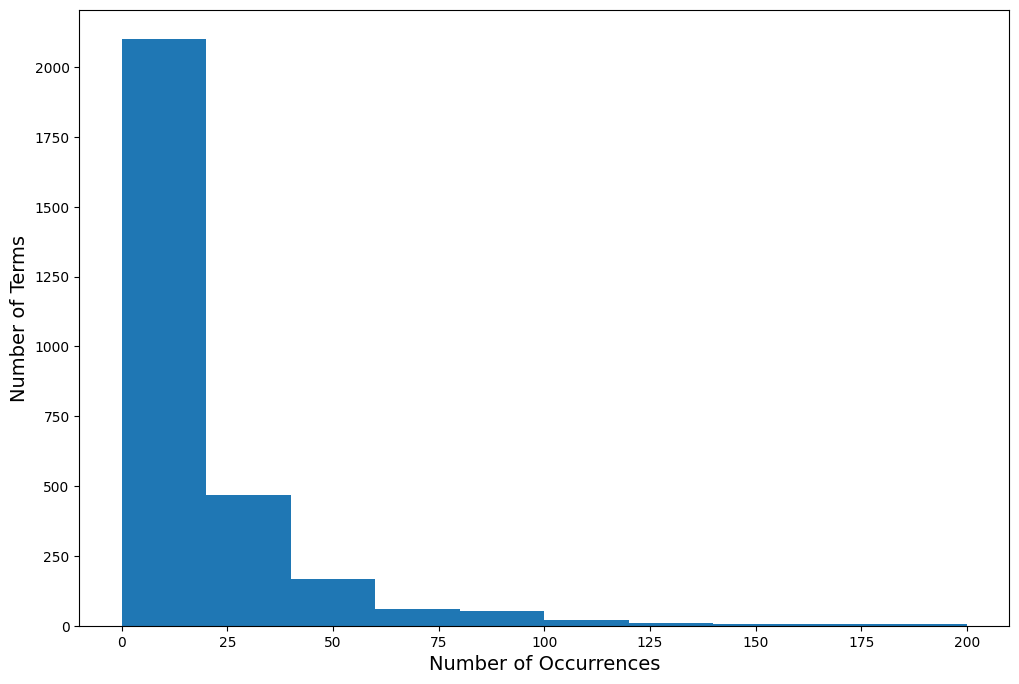

In [25]:
plt.figure(figsize = (12, 8))
plt.hist(doc_term_df.sum(axis=0).T, range=(0, 200))
plt.xlabel('Number of Occurrences',fontsize=14)
plt.ylabel('Number of Terms',fontsize=14);

In [26]:
# Re-tokenize words, recreate joined documents
corpus_df['lemmas'] = corpus_df.Text.apply(lambda x: get_lemmas(x, words_to_remove))
corpus_df['lemmas_joined'] = corpus_df.lemmas.apply(lambda x: ' '.join(x))
corpus_df.lemmas.head()

,lemmas
Doc_ID,
40,"[set, long, start, angel, fall, start, journey..."
41,"[people, enter, angel, fallen, local, cinema, ..."
42,"[ric, roman, angel, fallen, secret, service, a..."
43,"[certain, pleasure, fallen, watch, gerard, but..."
44,"[dont, need, olympus, fallen, andor, london, f..."


## Get Lemmatized and Filtered Sentences

Removes the additional words

In [27]:
corpus_df['sentences_lemmatized']=\
corpus_df.raw_sentences.apply(lambda x: [lemmatize_sentence(s, words_to_remove) for s in x])

In [28]:
corpus_df.head().T

Doc_ID,40,41,42,43,44
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen,KCM_Doc5_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...,There is a certain mindless pleasure in the Fa...,"No, you dont need to have seen Olympus Has F..."
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen,KCM_Doc5_AngelHasFallen
Student Name,KCM,KCM,KCM,KCM,KCM
Genre of Movie,Action,Action,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42,Action_Angel Has Fallen_N_43,Action_Angel Has Fallen_N_44
Doc_ID,40,41,42,43,44
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...,[There is a certain mindless pleasure in the F...,"[No, you dont need to have seen Olympus Has ..."


## Review Documents By Movie Title

In [29]:
print(corpus_df['Movie Title'].unique())

['Angel Has Fallen' 'Inception' 'No Time To Die' 'Taken' 'Taxi'
 'Despicable Me 3' 'Dirty Grandpa' 'Holmes and Watson' 'Legally Blonde'
 'The Lost City' 'Drag me to hell' 'Fresh' 'It Chapter Two'
 'The Toxic Avenger' 'US' 'Batman' 'Equilibrium' 'Minority Report'
 'Oblivion' 'Pitch Black']


In [30]:
# The movie the knowledge graph is built from. Taken from the corpus so the
# notebook runs against any quarter's; set it to any title printed above.
MOVIE_TITLE = sorted(corpus_df['Movie Title'].unique())[0]

movie_df = corpus_df[corpus_df['Movie Title'] == MOVIE_TITLE].copy()
if movie_df.empty:
    raise ValueError(
        f"No reviews found for {MOVIE_TITLE!r}. "
        f"Available titles: {sorted(corpus_df['Movie Title'].unique())}"
    )
print(f"Knowledge graph for: {MOVIE_TITLE}  ({len(movie_df)} reviews)")
movie_df.head(3).T

Knowledge graph for: Angel Has Fallen  (10 reviews)


Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Knowledge Graph Extraction

In [31]:
corpus_text_sentences = [y for x in movie_df.raw_sentences for y in x]
example_sentence = nlp(corpus_text_sentences[5])
corpus_text_sentences[5]

'Compared to the 15 minutes it took me to figure out the clothes appropriate for the day, it\x92s hard to figure out which effort was more difficult to do, or more fun.'

In [32]:
entity_pairs = [get_entities(x) for x in tqdm(corpus_text_sentences)]

100%|██████████| 366/366 [00:03<00:00, 121.00it/s]


In [33]:
entity_pairs

[['sets', 'long  Angel'],
 ['I', 'work something'],
 ['I', 'light cargo shorts'],
 ['two  who', 'said  movie'],
 ['total', 'two Gerard hours'],
 ['hard  effort', 'day'],
 ['going', 'local  mall'],
 ['I\x92ve', 'couple  hours'],
 ['new Friendly Fires record', 'shelves'],
 ['I', 'copy'],
 ['specific  reaction', 'news'],
 ['it', 'Morgan Angel'],
 ['again Freeman\x92s reactions', 'healthy  boredom'],
 ['actually  Freeman', 'bed  movie'],
 ['commanding  presence', '18 chase wheeler'],
 ['80 million 80 I', 'eventual movie ticket'],
 ['', ''],
 ['I', 'home Morgan Freeman'],
 ['by  all', 'damn shopping bags'],
 ['them', 'aside  .toughness'],
 ['', ''],
 ['', ''],
 ['mall that', 'miraculous  convoluted'],
 ['Fallen', 'rapidly  anything'],
 ['Maybe  it', 'four Victoria Secret bags'],
 ['', ''],
 ['I', 'just  burgers'],
 ['bright Angry that', 'rather  cider'],
 ['tiniest  element', 'friendly Butler\x92s character'],
 ['so  Butler', 'lines'],
 ['vocal  government', 'damn  lawn'],
 ['Nick Nolte', '

### Create DataFrame (Source, Target, Edge)

In [34]:
relations = [get_relation(x) for x in corpus_text_sentences]
#extract subject and object
source = [i[0] for i in entity_pairs]
target = [i[1] for i in entity_pairs]
kg_df = pd.DataFrame({'source': source, 'target': target, 'edge': relations})

### Knowledge Graph Preprocessing (Lowercase, Remove Empty Spaces)

In [35]:
# Move everything to lower case
kg_df.source = kg_df.source.str.lower()
kg_df.target = kg_df.target.str.lower()
kg_df.edge = kg_df.edge.str.lower()

# Filter out empties
kg_df = kg_df[kg_df.source != '']
kg_df = kg_df[kg_df.target != '']
kg_df = kg_df[kg_df.edge != ''].copy()

In [36]:
kg_df.head(6).T

,0,1,2,3,4,5
source,sets,i,i,two who,total,hard effort
target,long angel,work something,light cargo shorts,said movie,two gerard hours,day
edge,fallen,start,wear,kills,needed,took


In [37]:
kg_df.shape

(304, 3)

In [38]:
len(corpus_text_sentences)

366

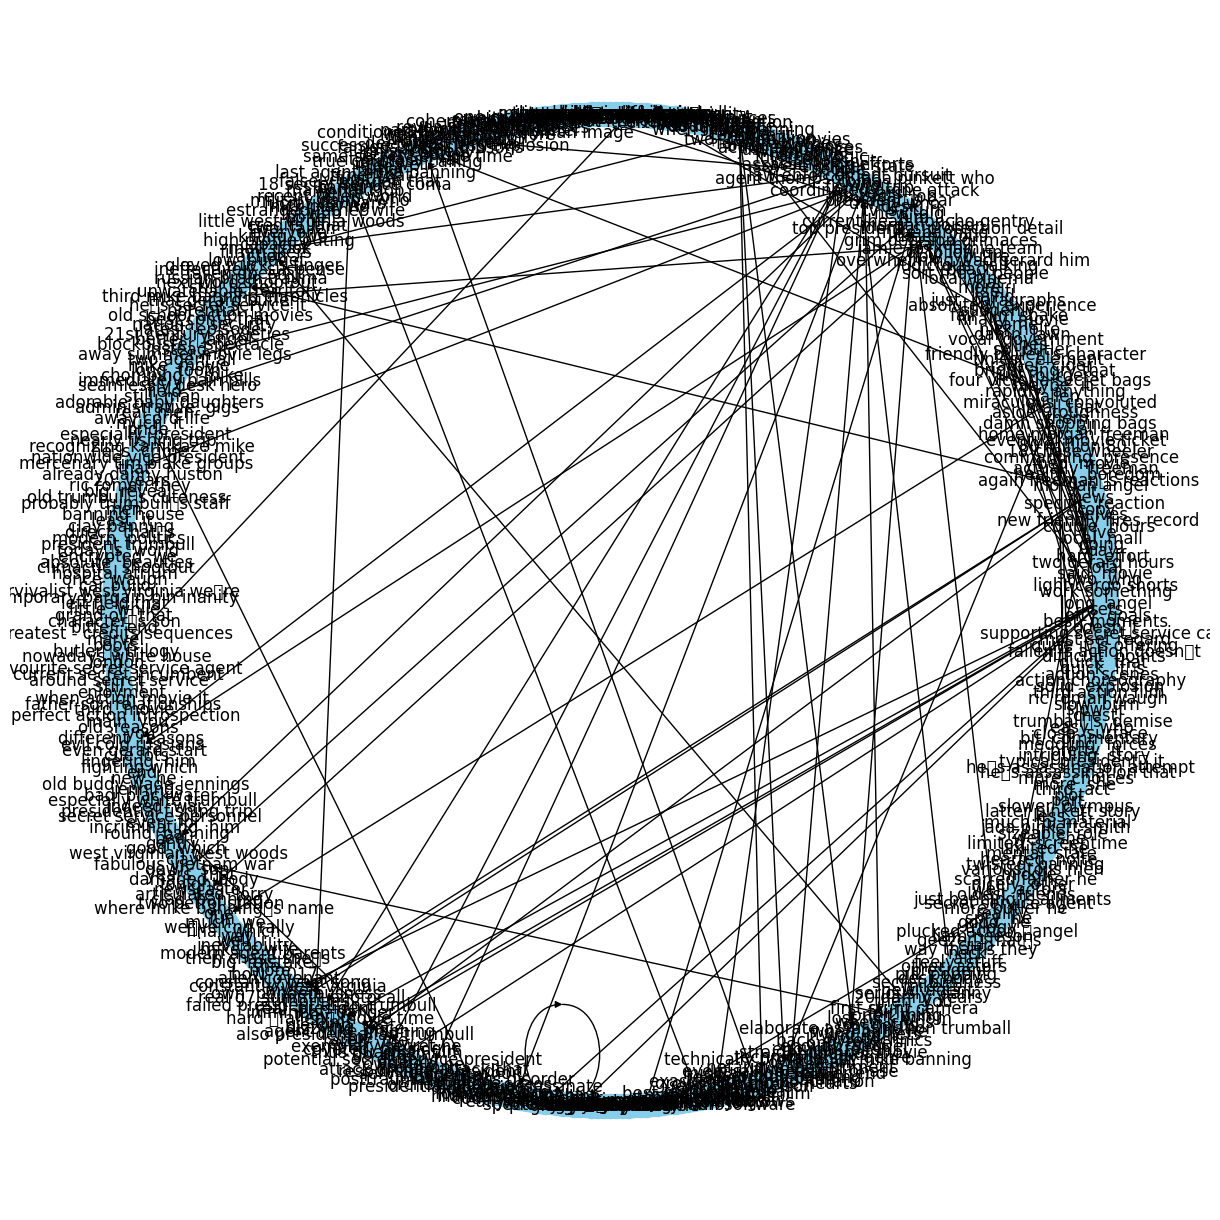

In [39]:
plot_graph(kg_df, use_circular=True)

BERT NER (Named Entity Recognition)

In [40]:
# NER Setup with BERT
def setup_ner_pipeline(model_name="dbmdz/bert-large-cased-finetuned-conll03-english"):
    """
    Set up the NER pipeline using the specified BERT model.
    """
    try:
        ner_pipeline = pipeline("ner", model=model_name, aggregation_strategy="simple")
        print("NER pipeline set up successfully.")
        return ner_pipeline
    except Exception as e:
        print(f"An error occurred while setting up the NER pipeline: {e}")
        return None

In [41]:
# Performing NER and Storing Results in DataFrames
def perform_ner_and_store_in_df(data, ner_pipeline):
    """
    Perform NER on the loaded dataset using the specified NER pipeline and store the results in DataFrames.
    The dataset should have 'title' and 'content' columns.
    """
    if data is not None and ner_pipeline is not None:
        titles = data['title']
        contents = data['content']
        df_dict = {}
        for title, text in zip(titles, contents):
            print ("Processing: ", title)
            entities = ner_pipeline(text)
            df_dict[title] = pd.DataFrame(entities)
        print("NER processing completed.")
        return df_dict
    else:
        print("Data or NER pipeline is not properly initialized.")
        return {}

In [42]:
# Set up the NER pipeline
ner_pipeline = setup_ner_pipeline()

# Make a new dataframe "data" for use with NER; copying and renaming columns
data_raw = corpus_df.rename(columns={'Movie Title': 'title', 'raw_sentences': 'content'}).copy()

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

NER pipeline set up successfully.


In [43]:
# TEST ON MOVIE REVIEWS FOR ONE MOVIE

# Sample title for testing

specific_title = MOVIE_TITLE  # set MOVIE_TITLE above to study a different film

# Example filtering for just one movie, can be extended with logical operators
data = data_raw.query("title == '"+ specific_title +"'").copy()
# For multiple titles, you can use or "|"
#data = data_raw.query("title == 'Movie Title 1' | title == 'Movie Title 2'").copy()

In [44]:
# OR IF YOU WANT TO DO NER FOR ALL MOVIE REVIEWS, uncomment this line:
#data= data_raw

In [45]:
# Perform NER on the dataset and store results in DataFrame
# This can take some time.
df_dict = perform_ner_and_store_in_df(data, ner_pipeline)

Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
Processing:  Angel Has Fallen
NER processing completed.


In [46]:
# Print all document titles in the NER resutls
df_dict.keys()

dict_keys(['Angel Has Fallen'])

In [47]:
# How the returned extracted data is represented...

# Raw form:
#df_dict
#print("========")

row_at_index_0 = df_dict[MOVIE_TITLE].iloc[0]
print(row_at_index_0)
print("========")

print(df_dict[MOVIE_TITLE].iloc[0,0])
print(df_dict[MOVIE_TITLE].iloc[1,0])
print(df_dict[MOVIE_TITLE].iloc[2,0])

0    {'entity_group': 'PER', 'score': 0.9996406, 'w...
1    {'entity_group': 'PER', 'score': 0.99438316, '...
2    {'entity_group': 'MISC', 'score': 0.99482816, ...
3                                                 None
4                                                 None
Name: 0, dtype: object
{'entity_group': 'PER', 'score': np.float32(0.9996406), 'word': 'Butler', 'start': 0, 'end': 6}
{'entity_group': 'PER', 'score': np.float32(0.99677587), 'word': 'Banning', 'start': 65, 'end': 72}
{'entity_group': 'PER', 'score': np.float32(0.9850117), 'word': 'Banning', 'start': 25, 'end': 32}


In [48]:
# Access and print the NER results DataFrame for a specific title

# Check if the specific title exists in the dictionary
if specific_title in df_dict:
    # Access the DataFrame for the specific title
    df_iter = df_dict[specific_title]

    # Initialize an empty list to collect all words (entities)
    all_entities = []

    # Iterate through each row of the DataFrame
    for index, row in df_iter.iterrows():
        # Iterate through each cell in the row
        for cell in row:
            # Check if the cell contains a dictionary and has the expected keys
            if isinstance(cell, dict) and {'entity_group', 'score', 'word', 'start', 'end'}.issubset(cell):
                # Extract entity information from the dictionary
                entity_group = cell['entity_group']
                score = cell['score']
                word = cell['word']
                start = cell['start']
                end = cell['end']

                # Collect the entity details
                all_entities.append({
                    "Entity": word,
                    "Type": entity_group,
                    "Score": score,
                    "Start": start,
                    "End": end
                })

                # Example: Print out the entity information
                print(f"Entity: {word}, Type: {entity_group}, Score: {score}, Start: {start}, End: {end}")

    # If you want to do something with all_entities later, it's available
else:
    print("Title not found in the results.")

Entity: Butler, Type: PER, Score: 0.9996405839920044, Start: 0, End: 6
Entity: Banning, Type: PER, Score: 0.9943831562995911, Start: 38, End: 45
Entity: Angel Has Fallen, Type: MISC, Score: 0.9948281645774841, Start: 49, End: 65
Entity: Banning, Type: PER, Score: 0.9967758655548096, Start: 65, End: 72
Entity: Banning, Type: PER, Score: 0.9850116968154907, Start: 25, End: 32
Entity: Butler, Type: PER, Score: 0.999617338180542, Start: 46, End: 52
Entity: Danny Huston, Type: PER, Score: 0.9972249865531921, Start: 98, End: 110
Entity: Banning, Type: PER, Score: 0.9778514504432678, Start: 195, End: 202
Entity: Danny Huston, Type: PER, Score: 0.9978817105293274, Start: 25, End: 37
Entity: Banning, Type: PER, Score: 0.9733954668045044, Start: 87, End: 94
Entity: Butler, Type: PER, Score: 0.9994729161262512, Start: 7, End: 13
Entity: Banning, Type: PER, Score: 0.9648581147193909, Start: 10, End: 17
Entity: Nick Nolte, Type: PER, Score: 0.9583144187927246, Start: 41, End: 51
Entity: Clay, Type:

In [49]:
# TRANSFER WORDS FROM NER DATA-STRUCTURE TO A SIMPLE LIST

# Initialize an empty list to collect all the "word" values
all_entities = []

# Iterate through each row in the DataFrame
for index, row in df_dict[MOVIE_TITLE].iterrows():
    # Iterate through each column/cell in the row
    for col in row.index:
        # Access the cell value, which is expected to be a dictionary
        cell_value = row[col]
        # Check if the cell value is a dictionary and has the key 'word'
        if isinstance(cell_value, dict) and 'word' in cell_value:
            # Add the "word" value from the dictionary to the list
            all_entities.append(cell_value['word'])

# Now, all_words contains all the "word" values extracted from the dictionaries
print(all_entities)

['Butler', 'Banning', 'Angel Has Fallen', 'Banning', 'Banning', 'Butler', 'Danny Huston', 'Banning', 'Danny Huston', 'Banning', 'Butler', 'Banning', 'Nick Nolte', 'Clay', 'Nolte', 'Banning', 'Banning', 'Nolte', 'Butler', 'Nolte', 'Clay', 'Morgan Freeman', 'Trumbull', 'Freeman', 'Randha Mitchell', 'Banning', 'Piper Perabo', 'Butler', 'Nolte', 'Jada Pinkett - Smith', 'Helen Thompson', 'FBI', 'Banning', 'Banning', 'Pinkett - Smith', 'Olympus', 'London Has Fallen', 'Banning', 'Angel Has Fallen', 'Banning', 'Thompson', 'FBI', 'Banning', 'Angel Has', 'Fallen', 'American', 'Banning', 'Trum', 'Ric Roman Waugh', 'Nolte', 'Banning', 'Olympus', 'London', 'Angel Has Fallen', 'Banning', 'Angel Has', 'Fallen', 'Butler', 'Secret Service', 'Banning', 'Angel Has Fallen']


In [50]:
# Find the lowercased words of all
all_entities= [word.lower() for word in all_entities]

entities_kg_df= find_sources_and_targets_with_patterns(all_entities, kg_df)

In [51]:
all_entities

['butler',
 'banning',
 'angel has fallen',
 'banning',
 'banning',
 'butler',
 'danny huston',
 'banning',
 'danny huston',
 'banning',
 'butler',
 'banning',
 'nick nolte',
 'clay',
 'nolte',
 'banning',
 'banning',
 'nolte',
 'butler',
 'nolte',
 'clay',
 'morgan freeman',
 'trumbull',
 'freeman',
 'randha mitchell',
 'banning',
 'piper perabo',
 'butler',
 'nolte',
 'jada pinkett - smith',
 'helen thompson',
 'fbi',
 'banning',
 'banning',
 'pinkett - smith',
 'olympus',
 'london has fallen',
 'banning',
 'angel has fallen',
 'banning',
 'thompson',
 'fbi',
 'banning',
 'angel has',
 'fallen',
 'american',
 'banning',
 'trum',
 'ric roman waugh',
 'nolte',
 'banning',
 'olympus',
 'london',
 'angel has fallen',
 'banning',
 'angel has',
 'fallen',
 'butler',
 'secret service',
 'banning',
 'angel has fallen']

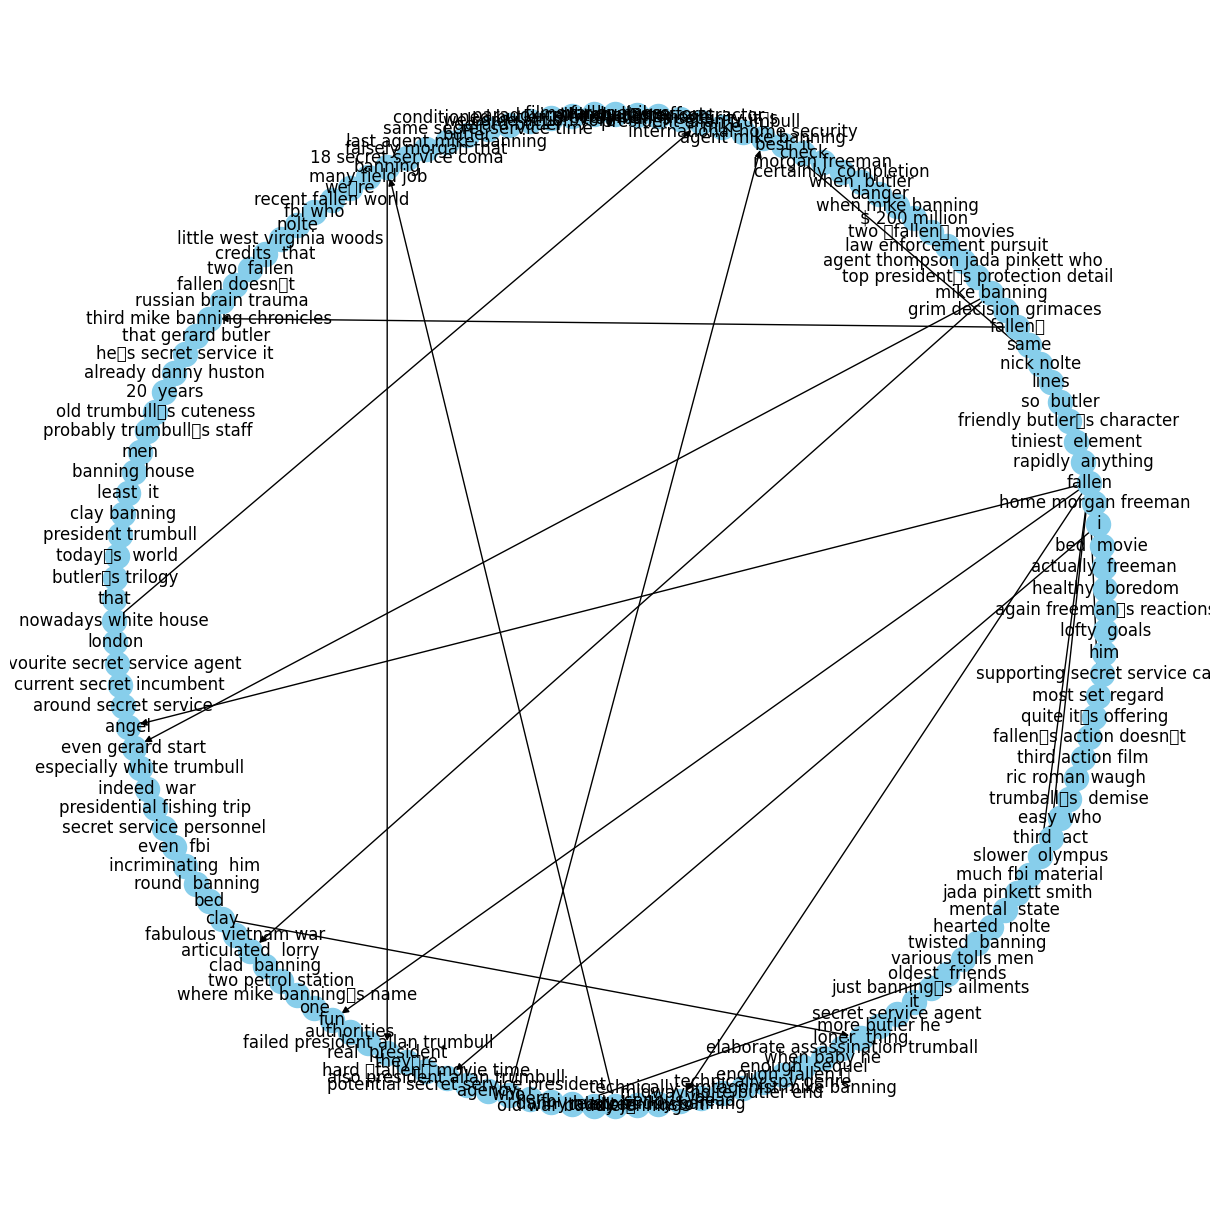

In [52]:
plot_graph(entities_kg_df, use_circular=True)

##BEGIN EXPERIMENTAL CODE


In [53]:
# I sometimes export the knowledge data-frames to Excel. I have found it useful to examine the results
# and hand edit the results and import them back for the semi-automated construction of the knowledge graph.

In [54]:
# kg_df.to_excel("kg.xlsx")

In [55]:
# For manual review or editing of the dataframes
#global_kg_df2.to_excel("kg2.xlsx")

In [56]:
# print(global_kg_df2)

In [57]:
# # Move everything to lower case
# global_kg_df2.source = global_kg_df2.source.str.lower()
# global_kg_df2.target = global_kg_df2.target.str.lower()
# global_kg_df2.edge = global_kg_df2.edge.str.lower()

# # Filter out empties
# global_kg_df2 = global_kg_df2[global_kg_df2.source != '']
# global_kg_df2 = global_kg_df2[global_kg_df2.target != '']
# global_kg_df2 = global_kg_df2[global_kg_df2.edge != ''].copy()

# # Filter out empties
# global_kg_df2 = global_kg_df2[global_kg_df2.source != 'NaN']
# global_kg_df2 = global_kg_df2[global_kg_df2.target != 'NaN']
# global_kg_df2 = global_kg_df2[global_kg_df2.edge != 'NaN'].copy()

In [58]:
# print(global_kg_df2)

In [59]:
# global_kg_df2.shape

In [60]:
# plot_graph(global_kg_df2, use_circular=True)

END EXPERIMENTAL CODE

## Recurrent Neural Network (RNN) Model Development

<img src="https://raw.githubusercontent.com/KartikNW/MSDS_453_Public/main/images/BidirectionalRNN.png">

<div class="alert alert-block alert-info">
    <b>tf.keras.layers.Bidirectional</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional
    </div>

In [61]:
datafull=corpus_df.copy()
datafull.reset_index(drop=True, inplace=True)
datafull.head(4).T

,0,1,2,3
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...,There is a certain mindless pleasure in the Fa...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Student Name,KCM,KCM,KCM,KCM
Genre of Movie,Action,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42,Action_Angel Has Fallen_N_43
Doc_ID,40,41,42,43
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...,[There is a certain mindless pleasure in the F...


In [62]:
datafull['Text'] = datafull['Text'].apply(lambda x :clean_doc(x))

## Preprocess DataSet

In [63]:
data = datafull[['Text','Genre of Movie']].copy()

In [64]:
data['Genre of Movie'] = data['Genre of Movie'].astype("category")
data['Genre of Movie code'] = data['Genre of Movie'].cat.codes
data['Genre of Movie code'].tail().T

,Genre of Movie code
195,3
196,3
197,3
198,3
199,3


## Review Examples by Genre

In [65]:
features, targets = data['Text'], data['Genre of Movie code']
data[["Genre of Movie","Genre of Movie code"]].value_counts()

,,count
Genre of Movie,Genre of Movie code,
Action,0,50
Comedy,1,50
Horror,2,50
Sci-Fi,3,50


## Create Datasets for Model Development

### Cell 10 - def get_dataset_partitions_pd

In [66]:
trainds, valds, testds = get_dataset_partitions_pd(data[['Text','Genre of Movie code']])
trainds.shape, valds.shape, testds.shape

((160, 2), (20, 2), (20, 2))

## Convert DataFrame to TensorFlow DataSet

In [67]:
# train X & y
train_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(trainds['Text'].values, tf.string)
)
train_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(trainds['Genre of Movie code'].values, tf.int64),
  )
# test X & y
test_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(testds['Text'].values, tf.string)
)
test_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(testds['Genre of Movie code'].values, tf.int64),
)
#val X & Y
val_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(valds['Text'].values, tf.string)
)
val_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(valds['Genre of Movie code'].values, tf.int64),
)

## Create DataSets (X=Preprocessed Text, Y=Encoded Categories)

In [68]:
train_ds = tf.data.Dataset.zip(
    (
            train_text_ds_raw,
            train_cat_ds_raw
     )
)
test_ds = tf.data.Dataset.zip(
    (
            test_text_ds_raw,
            test_cat_ds_raw
     )
)
val_ds = tf.data.Dataset.zip(
    (
            val_text_ds_raw,
            val_cat_ds_raw
     )
)

## Create Data Pipelines (Batching, Shuffling, and Optimizing)

In [69]:
batch_size = 3
AUTOTUNE = tf.data.experimental.AUTOTUNE
buffer_size=train_ds.cardinality().numpy()

train_ds = train_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)

test_ds = test_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)


val_ds = val_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Text                 200 non-null    object  
 1   Genre of Movie       200 non-null    category
 2   Genre of Movie code  200 non-null    int8    
dtypes: category(1), int8(1), object(1)
memory usage: 2.3+ KB


## Create the Text Encoder

The raw text loaded by `tfds` needs to be processed before it can be used in a model. The simplest way to process text for training is using the `experimental.preprocessing.TextVectorization` layer. This layer has many capabilities, but this tutorial sticks to the default behavior.

Create the layer, and pass the dataset's text to the layer's `.adapt` method:
The processing of each sample contains the following steps:

    standardize each sample (usually lowercasing + punctuation stripping)
    split each sample into substrings (usually words)
    recombine substrings into tokens (usually ngrams)
    index tokens (associate a unique int value with each token)
    transform each sample using this index, either into a vector of ints or a dense float vector.

<div class="alert alert-block alert-info">
    <b>tf.keras.layers.TextVectorization</b><br>
   https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
    </div>

In [71]:
VOCAB_SIZE=5000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE, standardize="lower_and_strip_punctuation", pad_to_max_tokens= True)
encoder.adapt(train_ds.map(lambda text, label: text), batch_size= None)

In [72]:
vocab = np.array(encoder.get_vocabulary())
len(vocab)

5000

In [73]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 's', 'the', 'film', 'i', '’', 'movie', 'one', 'like',
       'time', 'it', 'get', 'make', 'nt', 'character', 'even', 'but',
       'scene', 'much'], dtype='<U16')

In [74]:
vocab[-20:]

array(['welltodo', 'wellplaced', 'weil', 'weighed', 'weariness',
       'weaponry', 'weakling', 'waynes', 'watsonâ\x80\x99s',
       'wasnâ\x80\x99t', 'washedout', 'warrior', 'warrant', 'warming',
       'ward', 'wander', 'wally', 'wallow', 'wallop', 'walked'],
      dtype='<U16')

## Example of Encoded Words

In [75]:
encoded_example = encoder('encanto we dont talk about bruno no no').numpy()
encoded_example[:]

array([   1,  185,    1,  849, 3054,    1,  121,  121])

In [76]:
len(encoder.get_vocabulary())

5000

In [77]:
encoder(data['Text'][0])

<tf.Tensor: shape=(507,), dtype=int64, numpy=
array([   1,   56,   84,  111,  444,  233,  336,    5,  111, 2101,    7,
       2993,   43, 2542,   59, 2182,  220,   59,  673,    9, 2152, 2682,
       2999,    1,  221,    1,    1, 3266,    1,    5,  683,    1, 3127,
        362, 1629,    1,  653,    5,   72,   59,  762, 3860,    9,   57,
         23,    7,    1,    1, 4492,  117,   72, 1351,  117,  204,  117,
          1,   11,  515,    8,  472, 1067, 3349,  109,    1,  100, 4098,
       1708,   97,   40, 1212,  245,  444,  233,  336,  638,  458,   35,
         40, 1212,   30,  309,    7,   83, 1217,  629,   40, 1365,  243,
         85, 2518,   30, 1274,  482,  417,    1,  292,  201,   35,  278,
       1708, 1317,  155,  515,  596, 2542, 2572,  109,   58,  187,  596,
        831,  744,   92, 3058, 3319,  359,  993,   64,  483,  909, 1378,
       3397,    1,  284,  507,  278,  204,    5, 3169, 1378,    1, 4706,
         29,   42, 2453,    1, 1146, 2683,  318, 1186, 1019, 1941,    5,
     

In [78]:
for example, label in train_ds.take(1):
  print('texts: ', example.numpy()[:1])
  print()

texts:  [b"Surrealism appear ineffably bizarre , inquisitively titillating , depending purely viewer 's intellect . Though realm surrealism highly nebulous complex , even slight attempt improvisation sometimes go awry open Pandora 's Box , making task highly improbable nigh impossible . This facet reality may pose handicap gifted director , genius Christopher Nolan , dabbles concept surrealism , also ingeniously blend element Science Fiction latest wonder named Inception . Nolan created niche decade back unleashing monster movie called Memento . He substantiated status conjuring movie like Insomnia , The Prestige , Batman Begins , The Dark Knight . His unremitting desire innovation uncanny craving foray unexplored realm imagination deservedly earned auteur tag , gave carte blanche story-teller like Nolan desperately need . It 's highly apparent Nolan take every possible advantage liberty filming Inception . Inception dreamlike , dream superior thing conceived silver screen . With entwi

In [79]:
#

## Build RNN Sequential Model

<div class="alert alert-block alert-info">
    <b>tf.keras.layers</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers
    </div>

In [80]:
k.clear_session()
num_classes = 4

model_rnn = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True  # Use masking to handle variable sequence lengths
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(64)),  # Replaced LSTM with SimpleRNN
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # num_classes = 4
])

In [81]:
model_rnn.compile(optimizer= tf.keras.optimizers.Adam( )
                 ,loss=tf.keras.losses.SparseCategoricalCrossentropy()
                 ,metrics=['accuracy'])

In [82]:
%%time
history_rnn = model_rnn.fit(train_ds
             ,epochs=200
             ,validation_data=val_ds
             #,validation_steps=3
             ,callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)])

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.2062 - loss: 1.4241 - val_accuracy: 0.3000 - val_loss: 1.4004
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.4250 - loss: 1.3022 - val_accuracy: 0.4000 - val_loss: 1.3802
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.3500 - loss: 1.3676 - val_accuracy: 0.2500 - val_loss: 1.4739
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.3000 - loss: 1.4051 - val_accuracy: 0.2000 - val_loss: 1.4862
CPU times: user 12min 44s, sys: 54.8 s, total: 13min 38s
Wall time: 8min 40s


## Model Performance Test Accuracy - RNN

In [83]:
test_loss, test_acc = model_rnn.evaluate(test_ds)

print('Test Loss: {}'.format(test_loss))
print('Test Accuracy: {}'.format(test_acc))

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 343ms/step - accuracy: 0.4000 - loss: 1.3215
Test Loss: 1.3215337991714478
Test Accuracy: 0.4000000059604645


## Plotting Performance Metrics - RNN

In [84]:
history_rnn_dict = history_rnn.history
history_rnn_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [85]:
history_rnn_df=pd.DataFrame(history_rnn_dict)
history_rnn_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.206,1.424,0.30,1.400
1,0.425,1.302,0.40,1.380
2,0.350,1.368,0.25,1.474
3,0.300,1.405,0.20,1.486


In [86]:
losses_rnn = history_rnn.history['loss']
accs_rnn = history_rnn.history['accuracy']
val_losses_rnn = history_rnn.history['val_loss']
val_accs_rnn = history_rnn.history['val_accuracy']
epochs_rnn = len(losses_rnn)

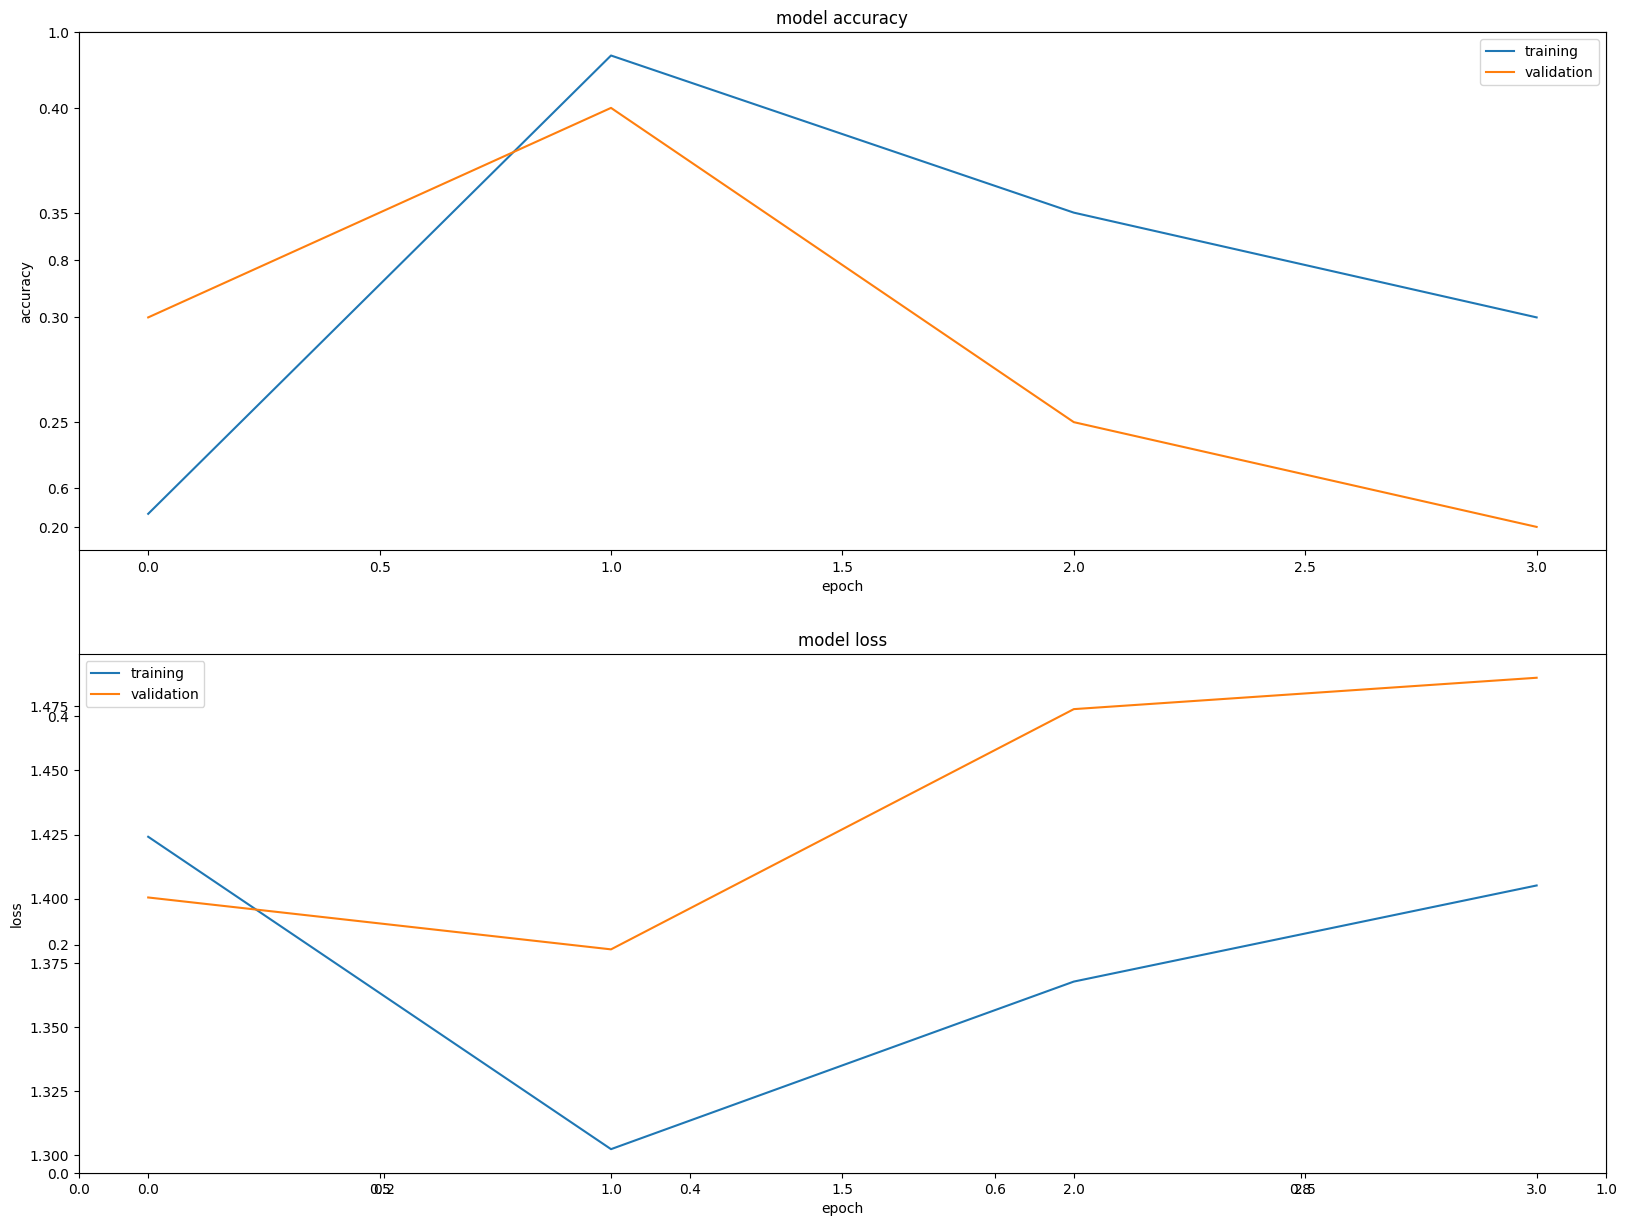

In [87]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_rnn.history['accuracy'], history_rnn.history['val_accuracy'], 'accuracy', 211)
display_training_curves(history_rnn.history['loss'], history_rnn.history['val_loss'], 'loss', 212)

## Confusion Matrix Post Model Performance Analysis - RNN

In [88]:
preds2_rnn = model_rnn.predict(test_ds)
y_pred2_rnn = np.argmax(preds2_rnn, axis=1)
y2_rnn = np.concatenate([y for x, y in test_ds], axis=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 400ms/step


In [89]:
CLASSES_LIST = ['Action','Comedy','Horror','Sci Fi']

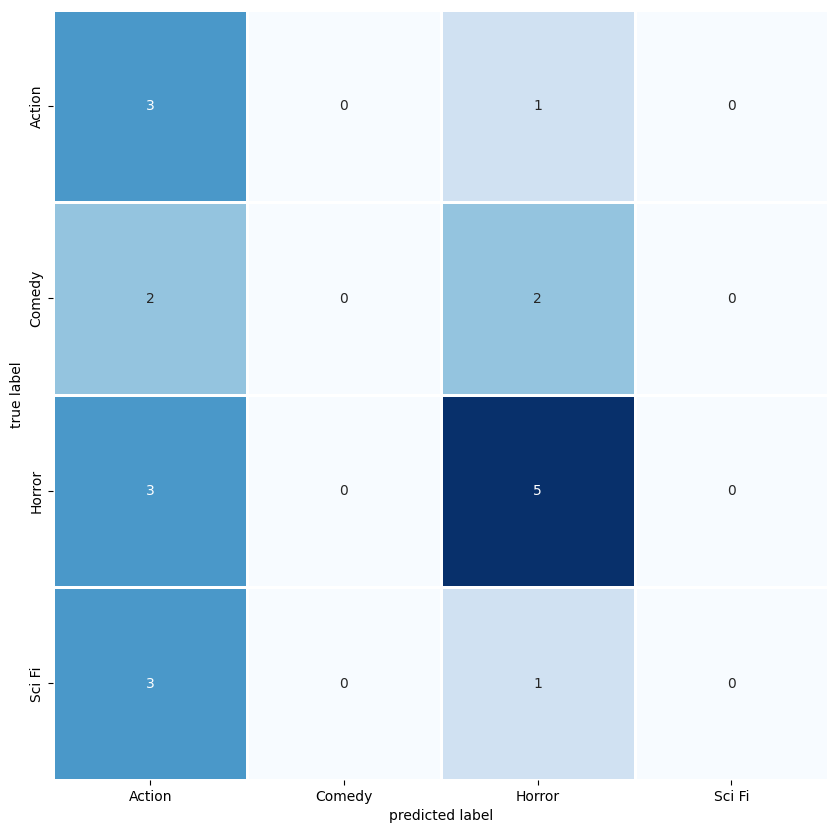

In [90]:
plot_confusion_matrix_labeled(y2_rnn,y_pred2_rnn, CLASSES_LIST=CLASSES_LIST)

In [91]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)

In [92]:
df2_rnn = pd.DataFrame(preds2_rnn[0:15]
                  ,columns = CLASSES_LIST).T
df2_rnn.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Action,25.17%,29.66%,33.99%,34.91%,28.66%,37.07%,33.84%,30.78%,34.24%,36.81%,30.51%,37.24%,34.76%,31.99%,23.37%
Comedy,12.39%,14.28%,21.09%,11.32%,16.77%,20.46%,21.76%,14.30%,13.03%,18.95%,21.33%,20.02%,11.39%,18.08%,22.40%
Horror,48.65%,31.11%,26.85%,31.17%,45.66%,25.12%,35.13%,31.08%,24.81%,26.28%,39.76%,25.12%,26.57%,30.54%,46.87%
Sci Fi,13.80%,24.95%,18.07%,22.60%,8.91%,17.34%,9.27%,23.84%,27.92%,17.95%,8.40%,17.63%,27.28%,19.39%,7.36%


## RNN Model Architecture

In [93]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035,086 (3.95 MB)

 Trainable params: 345,028 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 690,058 (2.63 MB)

In [94]:
#

## Build LSTM Sequential Model

<div class="alert alert-block alert-info">
    <b>tf.keras.layers</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers
    </div>

In [95]:
k.clear_session()
num_classes=4
model_lstm=tf.keras.Sequential([encoder
   ,tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True)
   ,tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True, dropout=0.3))
   ,tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32,dropout=0.3))
   ,tf.keras.layers.Dense(64, activation='relu')
   ,tf.keras.layers.Dense(num_classes,activation='softmax')
])

In [96]:
model_lstm.compile(optimizer= tf.keras.optimizers.Adam( )
                   ,loss=tf.keras.losses.SparseCategoricalCrossentropy()
                   ,metrics=['accuracy'])

In [97]:
%%time
history_lstm = model_lstm.fit(train_ds
         ,epochs=200
         ,validation_data=val_ds
         #,validation_steps=3
         ,callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)])

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.1562 - loss: 1.3902 - val_accuracy: 0.4000 - val_loss: 1.3829
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.4250 - loss: 1.1987 - val_accuracy: 0.5000 - val_loss: 1.0366
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.6313 - loss: 0.8631 - val_accuracy: 0.6000 - val_loss: 1.0190
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7750 - loss: 0.6776 - val_accuracy: 0.4000 - val_loss: 1.1353
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8938 - loss: 0.3617 - val_accuracy: 0.5500 - val_loss: 1.1227
CPU times: user 28.6 s, sys: 478 ms, total: 29.1 s
Wall time: 28.4 s


## Model Performance Test Accuracy - LSTM

In [98]:
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(test_ds)

print('Test Loss: {}'.format(test_loss_lstm))
print('Test Accuracy: {}'.format(test_acc_lstm))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6500 - loss: 0.8297
Test Loss: 0.8296982645988464
Test Accuracy: 0.6499999761581421


## Plotting Performance Metrics - Multi-Layer Bidirectional LSTM

In [99]:
history_lstm_dict = history_lstm.history
history_lstm_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [100]:
history_lstm_df=pd.DataFrame(history_lstm_dict)
history_lstm_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.156,1.390,0.40,1.383
1,0.425,1.199,0.50,1.037
2,0.631,0.863,0.60,1.019
3,0.775,0.678,0.40,1.135
4,0.894,0.362,0.55,1.123


In [101]:
losses_lstm = history_lstm.history['loss']
accs_lstm = history_lstm.history['accuracy']
val_losses_lstm = history_lstm.history['val_loss']
val_accs_lstm = history_lstm.history['val_accuracy']
epochs_lstm = len(losses_lstm)

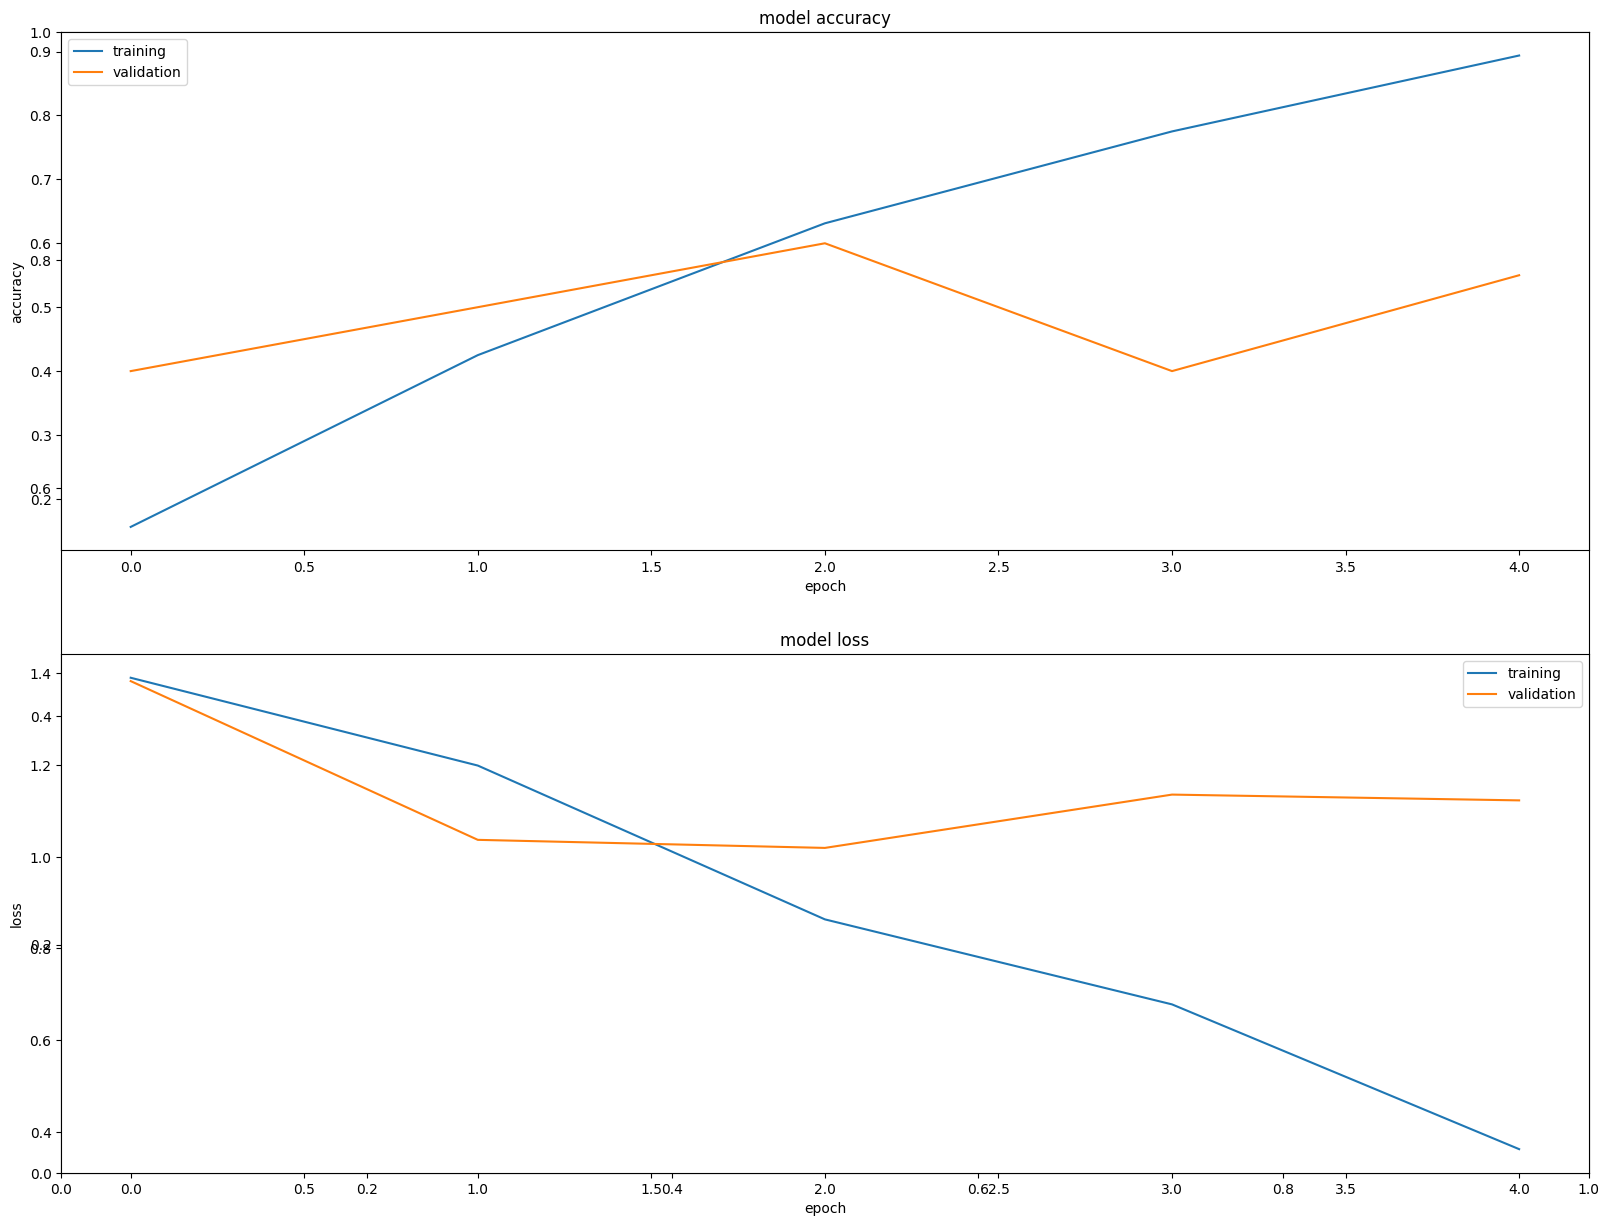

In [102]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_lstm.history['accuracy'], history_lstm.history['val_accuracy'], 'accuracy', 211)
display_training_curves(history_lstm.history['loss'], history_lstm.history['val_loss'], 'loss', 212)

## Confusion Matrix Post Model Performance Analysis - LSTM

In [103]:
preds2_lstm = model_lstm.predict(test_ds)
y_pred2_lstm = np.argmax(preds2_lstm, axis=1)
y2_lstm = np.concatenate([y for x, y in test_ds], axis=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


In [104]:
CLASSES_LIST = ['Action','Comedy','Horror','Sci Fi']

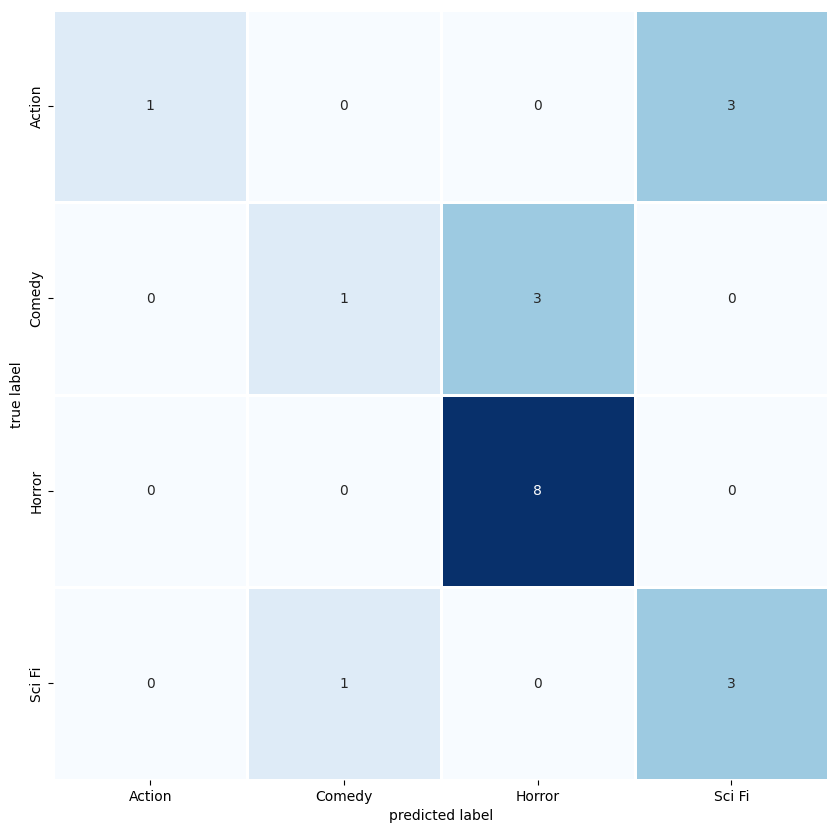

In [105]:
plot_confusion_matrix_labeled(y2_lstm,y_pred2_lstm, CLASSES_LIST=CLASSES_LIST)

In [106]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)

In [107]:
df2_lstm = pd.DataFrame(preds2_lstm[0:15]
                  ,columns = CLASSES_LIST).T
df2_lstm.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Action,0.01%,15.11%,44.63%,40.01%,0.01%,0.02%,0.04%,0.03%,5.24%,0.00%,0.17%,6.62%,6.39%,0.05%,0.07%
Comedy,1.44%,15.30%,6.15%,15.33%,0.86%,1.41%,2.11%,1.64%,37.58%,0.81%,79.11%,38.09%,33.38%,4.83%,4.73%
Horror,98.00%,0.49%,0.12%,7.62%,98.85%,97.93%,96.84%,97.39%,1.23%,98.93%,17.49%,1.00%,1.58%,93.92%,93.66%
Sci Fi,0.55%,69.09%,49.10%,37.05%,0.28%,0.64%,1.01%,0.94%,55.94%,0.25%,3.23%,54.29%,58.64%,1.20%,1.54%


## LSTM Model Architecture

In [108]:
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295,054 (4.94 MB)

 Trainable params: 431,684 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 863,370 (3.29 MB)

In [109]:
!pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                3.0.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.1
altair                                5.5.0
annotated-doc                         0.0.5
annotated-types                       0.8.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
anywidget                             0.9.21
apsw                                  3.53.4.0

In [110]:
!pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==3.0.1
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.1
altair==5.5.0
annotated-doc==0.0.5
annotated-types==0.8.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.4.0
argon2-cffi==25.1.0
argon2-cffi-bindings==26.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.8.31.0.57.9
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioop-lts==0.2.2
audioread==3.1.0
Authlib==1.8.0
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b7
bigframes==2.48.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.3.0
blosc2==4.12.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.7.22
cffi==2.1.1
cha

In [111]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete | Version: {NOTEBOOK_VERSION} | {QUARTER}")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
if USING_SAMPLE_CORPUS:
    print("!!  This run used the SAMPLE corpus, not your class corpus. "
          "Do not write your report from these results.")

✅ Notebook complete | Version: 32.0 | Fall 2026
Total time:  15m 4s
Current time: 2026-09-21 02:27:18
!!  This run used the SAMPLE corpus, not your class corpus. Do not write your report from these results.
